In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Ahora importa el módulo
from RRAM.Representate import config_ax, setup_paper_plt


#### Varias Experimentales

In [16]:
setup_paper_plt(plt, latex=True, scaling=3)
plt.rc("xtick", labelsize=36)
plt.rc("ytick", labelsize=36)
fig, axes = plt.subplots(1, 1, figsize=(12, 9))
config_ax(axes)

numero_curvas = [1000]
for num_curva in numero_curvas: # cuidado que el ultimo valor NO lo coge 
    # print(f"Procesando curva {num_curva}")
    
    # Rutas de los archivos experimentales
    ruta_archivo_set = (
        os.getcwd() + f"/Datos_Experimentales/Ciclos_Experimentales/Cycle_p_{num_curva}.txt"
    )
    ruta_archivo_reset = (
        os.getcwd() + f"/Datos_Experimentales/Ciclos_Experimentales/Cycle_n_{num_curva}.txt"
    )
    # Cargar datos experimentales
    data_set = np.loadtxt(ruta_archivo_set)
    data_reset = np.loadtxt(ruta_archivo_reset)
    
    x_set = data_set[:, 0]
    y_set = abs(data_set[:, 1])
    
    x_reset = data_reset[:, 0]
    y_reset = abs(data_reset[:, 1])
    
    if num_curva == 1002:
        # Configuración de los ejes
        axes.plot(x_set, y_set, "blue", label="Set", linewidth=2)
        axes.plot(x_reset, y_reset, "blue", label="Reset", linewidth=2)
        # axes.set_xlim(-1.55, 1.25)
        
    if num_curva == 989:
        pass   
    else:
        # Curvas experimentales
        axes.plot(x_set, y_set, "blue", linewidth=2)
        axes.plot(x_reset, y_reset, "green", linewidth=2, label=f"Curva {num_curva}")
    
    axes.set_yscale("log")
    axes.set_xlabel(r"Voltage (\si{\volt})", fontsize=40)
    axes.set_ylabel(r"Current (\si{\ampere)", fontsize=40)
    
    # Leyenda ajustada en la parte inferior izquierda
    axes.legend(
        labelspacing=0.3,
        handletextpad=0.2,
        handlelength=1.0,
        borderaxespad=0.2,
        loc="lower left",
    )
    axes.legend()

# Guardar figura
fig.savefig(
    os.getcwd() + f"/Datos_Experimentales/Curvas_Ciclo_{num_curva}.png",
    bbox_inches="tight",
    dpi=600,
)

plt.close(fig)  # Cierra para liberar memoria

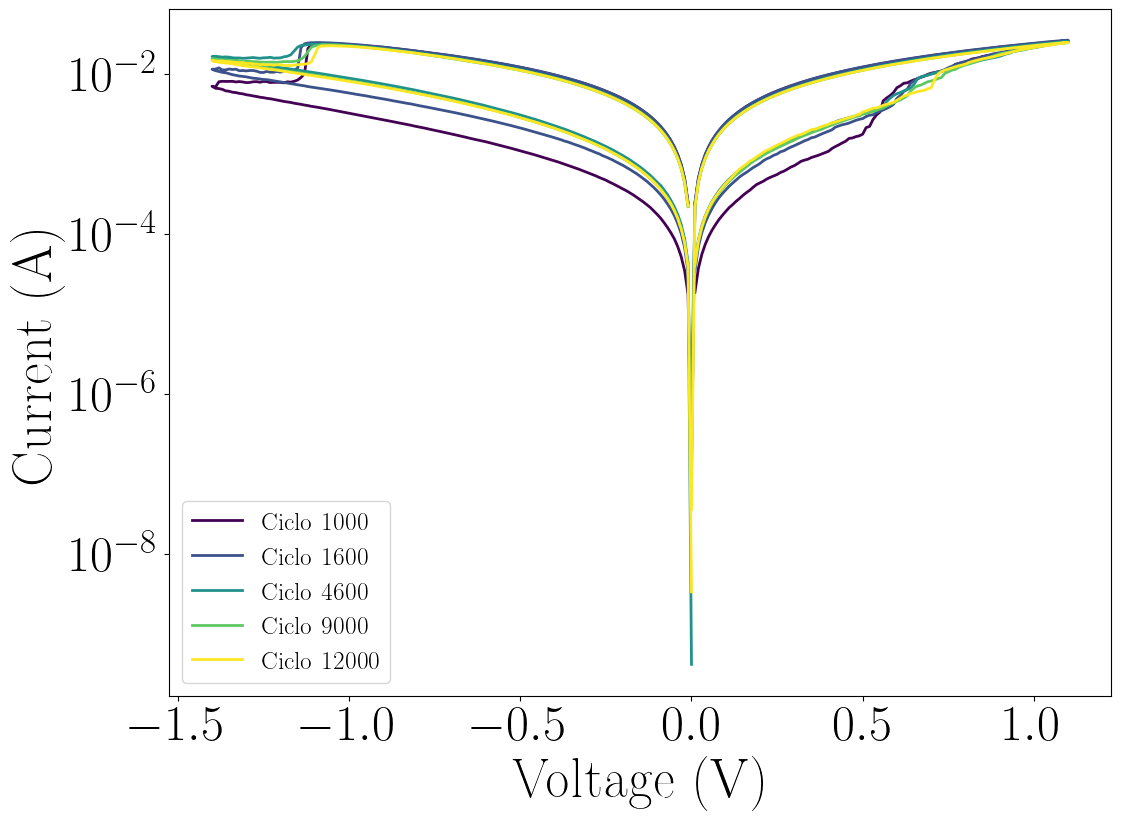

In [18]:
# --- Configuración de estilo ---
# setup_paper_plt(plt, latex=True, scaling=3)
plt.rc("xtick", labelsize=36)
plt.rc("ytick", labelsize=36)

fig, axes = plt.subplots(1, 1, figsize=(12, 9))
# config_ax(axes)

# --- Define tu lista de ciclos ---
lista_curvas = [1000, 1600, 4600, 9000, 12000]  # Ajusta según tus necesidades

# Generamos una gama de colores basada en la cantidad de curvas
# 'viridis' es una buena opción, pero puedes usar 'jet', 'rainbow' o 'plasma'
colores = plt.cm.viridis(np.linspace(0, 1, len(lista_curvas)))

for i, num_curva in enumerate(lista_curvas):
    # 1. Rutas de archivos
    ruta_set = os.path.join(os.getcwd(), "Datos_Experimentales", "Ciclos_Experimentales", f"Cycle_p_{num_curva}.txt")
    ruta_reset = os.path.join(os.getcwd(), "Datos_Experimentales", "Ciclos_Experimentales", f"Cycle_n_{num_curva}.txt")

    if os.path.exists(ruta_set) and os.path.exists(ruta_reset):
        # 2. Carga de datos
        data_set = np.loadtxt(ruta_set)
        data_reset = np.loadtxt(ruta_reset)

        color_actual = colores[i]  # Asignamos el color de la paleta

        # 3. Representación (Set y Reset con el mismo color)
        # Ponemos el label solo en el primer plot de cada ciclo para no duplicar en la leyenda
        axes.plot(data_set[:, 0], abs(data_set[:, 1]), color=color_actual, linewidth=2, label=f"Ciclo {num_curva}")
        axes.plot(data_reset[:, 0], abs(data_reset[:, 1]), color=color_actual, linewidth=2)
    else:
        print(f"Error: No se encontró el ciclo {num_curva}")

# --- Formateo final ---
axes.set_yscale("log")
axes.set_xlabel(r"Voltage (\si{\volt})", fontsize=40)
axes.set_ylabel(r"Current (\si{\ampere})", fontsize=40)

# Configuración de leyenda
axes.legend(
    loc="best",  # 'best' busca automáticamente el lugar con menos solapamiento
    fontsize=18,
    frameon=True,
    ncol=1,  # Puedes aumentar el número de columnas si tienes muchas curvas
)

plt.tight_layout()
plt.show()
